## Spotify Song Clustering and pattern Discovery Using Unsupervised Machine Learning

 ## Objective

The main objective of this project is to group Spotify tracks based on their audio features using unsupervised machine learning techniques.

The project aims to:
- Explore and understand the audio features of Spotify tracks.
- Clean and preprocess the dataset.
- Apply clustering algorithms such as K-Means, Hierarchical Clustering, and DBSCAN.
- Identify patterns and similarities between songs based on their audio characteristics.
- Evaluate the clustering results using Silhouette Score and Davies-Bouldin Index.
- Develop a simple Streamlit application to predict the cluster of a song based on its audio features.

In [1]:
## Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("Spotify Tracks.csv")

In [3]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
df.shape

(114000, 20)

In [5]:
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

In [6]:
df.dtypes

track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

## EDA 


In [8]:

df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## insight
Dataset contains 114,000 songs.
Average popularity is approximately 33.24, with values ranging from 0 to 100.
Average duration is around 228 seconds (about 3.8 minutes).
Average danceability is 0.57, indicating a moderate level of danceability.
Average energy is 0.64, showing that the dataset contains many relatively energetic songs.
Loudness has a mean of approximately -8.26 dB.
Acousticness has a mean of 0.31, while instrumentalness has a mean of 0.16.
Average tempo is approximately 122 BPM.
Most songs have a time signature of 4, as shown by the median and 75th percentile.
Some features, especially duration_ms, have a wide range, indicating the presence of potential outliers.

In [9]:
df.nunique()

track_id            89741
artists             31437
album_name          46589
track_name          73608
popularity            101
duration_ms         50697
explicit                2
danceability         1174
energy               2083
key                    12
loudness            19480
mode                    2
speechiness          1489
acousticness         5061
instrumentalness     5346
liveness             1722
valence              1790
tempo               45653
time_signature          5
track_genre           114
dtype: int64

## Insight
track_id has 89,741 unique values out of 114,000 rows. This means some tracks are repeated in the dataset.
artists has 31,437 unique artists.
album_name has 46,589 unique albums.
track_name has 73,608 unique track names.
popularity ranges from 0–100, giving 101 possible values.
explicit and mode are binary features with 2 unique values.
key has 12 unique values, representing musical keys.
track_genre has 114 unique genres.
time_signature has 5 unique values.
Audio features such as danceability, energy, loudness, tempo, etc. have many unique values, making them useful candidates for clustering

In [10]:
df['track_genre'].nunique()

114

In [11]:
df['track_genre'].value_counts().head(20)

track_genre
acoustic             1000
punk-rock            1000
progressive-house    1000
power-pop            1000
pop                  1000
pop-film             1000
piano                1000
party                1000
pagode               1000
opera                1000
new-age              1000
mpb                  1000
minimal-techno       1000
metalcore            1000
metal                1000
mandopop             1000
malay                1000
latino               1000
latin                1000
kids                 1000
Name: count, dtype: int64

In [12]:
df.isnull().sum()

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [13]:
print(df.duplicated().sum())

450


## Insight
The dataset contains 450 duplicate rows. These duplicate records can affect clustering results by giving repeated observations more weight. Therefore, they should be removed during the Data Cleaning stage.

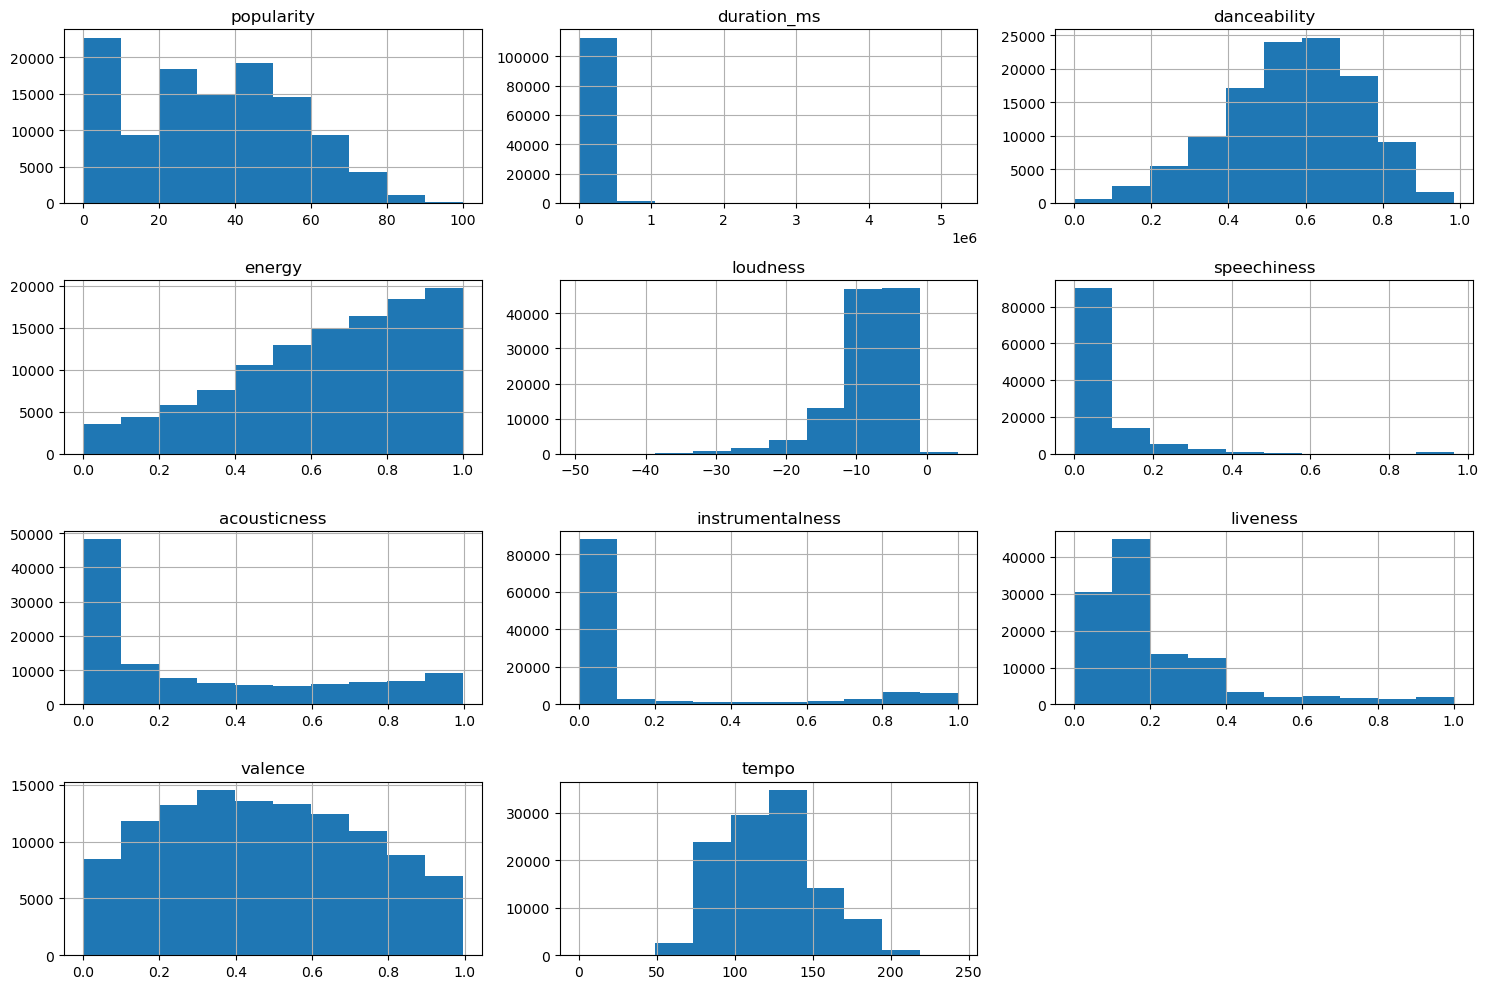

In [14]:
## Numerical Feature Distribution

numeric_features = [
    'popularity',
    'duration_ms',
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

df[numeric_features].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

##  Insight
From the histograms:
Popularity is spread across 0–100, with more songs having low-to-medium popularity.
Duration is highly right-skewed, with most songs having shorter durations and a few very long tracks.
Danceability is mostly concentrated around 0.4–0.8.
Energy is distributed broadly, with many songs having medium-to-high energy.
Loudness is concentrated around higher negative dB values, with a few unusual values.
Speechiness is highly right-skewed; most songs have low speech content.
Acousticness is also highly skewed, with many songs having low acousticness.
Instrumentalness contains many values close to zero and fewer highly instrumental tracks.
Liveness is mostly concentrated at lower values.
Valence is fairly spread across 0–1, representing different musical moods.
Tempo is mainly concentrated around approximately 100–150 BPM.

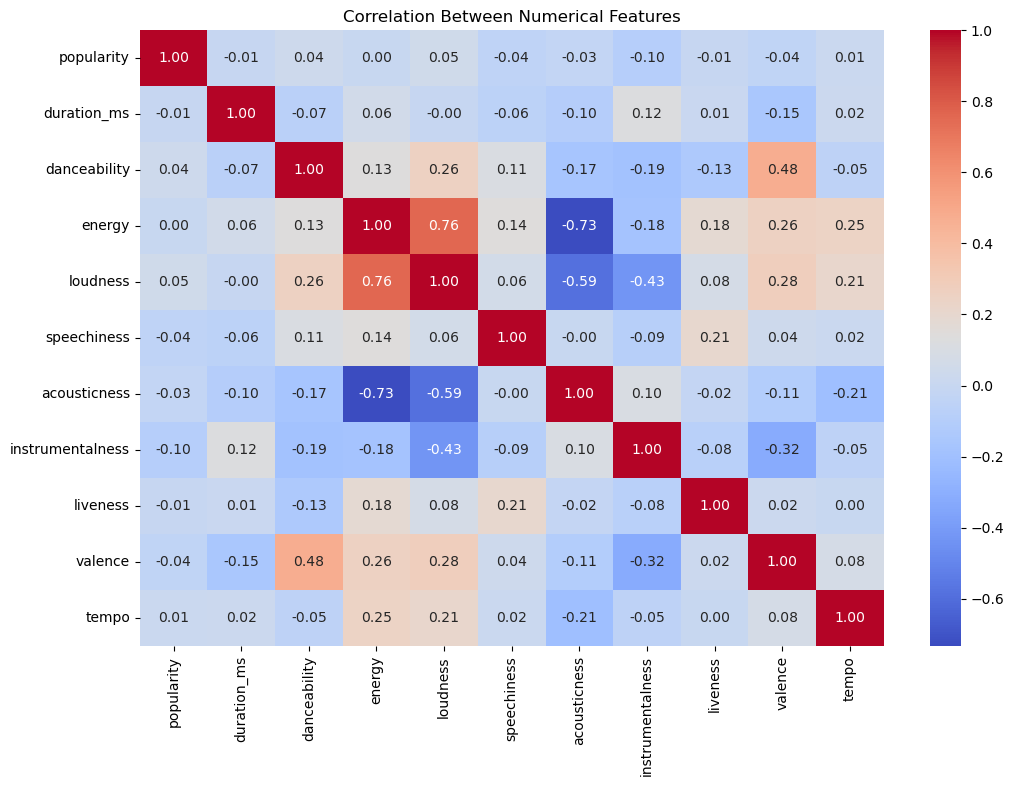

In [15]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df[numeric_features].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Between Numerical Features')
plt.show()

## Data Cleaning

In [16]:
df = df.drop_duplicates()

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.shape

(113550, 20)

In [19]:
## Handling Missing Values

df = df.dropna(subset=['artists','album_name', 'track_name'])

In [20]:
df.isnull().sum()

track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [21]:
df.shape

(113549, 20)

In [22]:
## feature selection

features = [
    'duration_ms',
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

X = df[features]

In [23]:
X.head()

,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,230666,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.715,87.917
1,149610,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.267,77.489
2,210826,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.120,76.332
3,201933,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.143,181.740
4,198853,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.167,119.949


In [24]:
X.shape

(113549, 10)

## Insight
Ten numerical audio features were selected to represent the musical characteristics of each track. Textual identifiers and genre labels were excluded because the objective is to discover natural clusters without using predefined categories.

In [25]:
## Feature Scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled,columns=features, index=X.index)

In [26]:
X_scaled.describe()

,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,1.135490e+05,1.135490e+05,1.135490e+05,1.135490e+05,1.135490e+05,1.135490e+05,1.135490e+05,1.135490e+05,1.135490e+05,1.135490e+05
mean,-1.181432e-16,2.422938e-16,3.604370e-17,9.611653e-17,-1.041262e-16,-1.601942e-17,3.203884e-17,4.805827e-17,3.203884e-17,-1.501821e-16
std,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00
min,-2.062682e+00,-3.269919e+00,-2.557599e+00,-8.238735e+00,-8.006181e-01,-9.462459e-01,-5.035417e-01,-1.121556e+00,-1.829478e+00,-4.076218e+00
25%,-5.064941e-01,-6.402881e-01,-6.735288e-01,-3.501202e-01,-4.611744e-01,-8.956290e-01,-5.035417e-01,-6.070150e-01,-8.264012e-01,-7.633497e-01
50%,-1.417254e-01,7.478708e-02,1.709172e-01,2.487146e-01,-3.382561e-01,-4.400769e-01,-5.034081e-01,-4.285008e-01,-3.937156e-02,-5.196197e-03
75%,3.148746e-01,7.379616e-01,8.440841e-01,6.470065e-01,-1.649001e-03,8.494490e-01,-3.460464e-01,3.118083e-01,8.055279e-01,5.971495e-01
max,4.707349e+01,2.410315e+00,1.425636e+00,2.549270e+00,8.323703e+00,2.054613e+00,2.730447e+00,4.128863e+00,2.009220e+00,4.043538e+00


### Insight

Feature scaling was performed using StandardScaler to bring all selected audio features to a comparable scale. This is important because features such as duration and tempo have different numerical ranges. Scaling helps prevent features with larger values from dominating the clustering process.

In [27]:
df.nlargest(10, 'duration_ms')[['track_name', 'duration_ms']]

,track_name,duration_ms
73617,Unity (Voyage Mix) Pt. 1,5237295
10935,Crossing Wires 002 - Continuous DJ Mix,4789026
24348,The Lab 03 - Continuous DJ Mix Part 1,4730302
73840,Amnesia Ibiza Underground 10 DJ Mix,4563897
13344,House of Om - Mark Farina - Continuous Mix,4447520
13245,Live In Tokyo - Continuous Mix,4339826
13195,Greenhouse Construction,4334721
27926,"NQ State of Mind, Vol. 1 - Continuous DJ Mix",4246206
101390,Ocean Waves Sounds,4120258
45063,Internal Flight (Remastered),3876276


In [28]:
df['duration_ms'].quantile([0.95, 0.99, 0.995, 0.999])

0.950    387146.00
0.990    530902.64
0.995    605332.18
0.999    996032.48
Name: duration_ms, dtype: float64

In [29]:
## Duration outliers cap

X = df[features].copy()

duration_limit = X['duration_ms'].quantile(0.99)

X['duration_ms'] = X['duration_ms'].clip(
    upper=duration_limit
)

print("99th percentile:", duration_limit)
print("Maximum duration after capping:", X['duration_ms'].max())

99th percentile: 530902.64
Maximum duration after capping: 530902.64


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=features,
    index=X.index
)

X_scaled.describe()


,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,1.135490e+05,1.135490e+05,1.135490e+05,1.135490e+05,1.135490e+05,1.135490e+05,1.135490e+05,1.135490e+05,1.135490e+05,1.135490e+05
mean,-5.206312e-17,2.422938e-16,3.604370e-17,9.611653e-17,-1.041262e-16,-1.601942e-17,3.203884e-17,4.805827e-17,3.203884e-17,-1.501821e-16
std,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00
min,-2.642012e+00,-3.269919e+00,-2.557599e+00,-8.238735e+00,-8.006181e-01,-9.462459e-01,-5.035417e-01,-1.121556e+00,-1.829478e+00,-4.076218e+00
25%,-6.277224e-01,-6.402881e-01,-6.735288e-01,-3.501202e-01,-4.611744e-01,-8.956290e-01,-5.035417e-01,-6.070150e-01,-8.264012e-01,-7.633497e-01
50%,-1.555750e-01,7.478708e-02,1.709172e-01,2.487146e-01,-3.382561e-01,-4.400769e-01,-5.034081e-01,-4.285008e-01,-3.937156e-02,-5.196197e-03
75%,4.354365e-01,7.379616e-01,8.440841e-01,6.470065e-01,-1.649001e-03,8.494490e-01,-3.460464e-01,3.118083e-01,8.055279e-01,5.971495e-01
max,3.711308e+00,2.410315e+00,1.425636e+00,2.549270e+00,8.323703e+00,2.054613e+00,2.730447e+00,4.128863e+00,2.009220e+00,4.043538e+00


## K-Means Clustering

In [31]:
## Elbow method

from sklearn.cluster import KMeans

inertia =[]

for k in range (2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

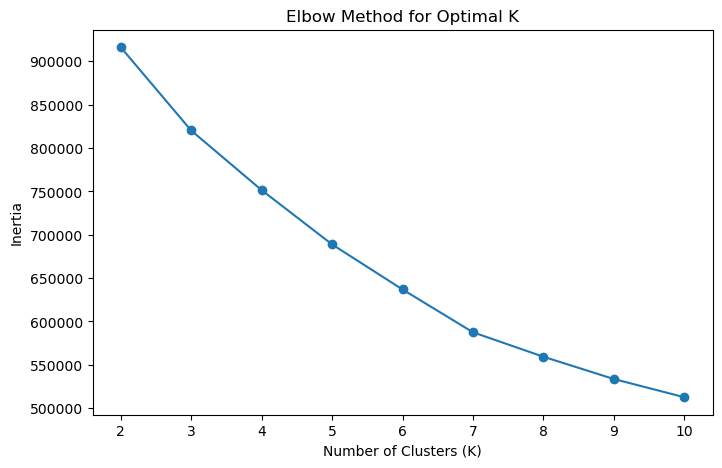

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(range(2, 11))
plt.show()

In [33]:
for k, value in zip(range(2, 11), inertia):
    print(f"K = {k}, Inertia = {value:.2f}")

K = 2, Inertia = 916261.59
K = 3, Inertia = 820242.37
K = 4, Inertia = 751486.86
K = 5, Inertia = 688879.64
K = 6, Inertia = 636913.38
K = 7, Inertia = 587515.44
K = 8, Inertia = 559331.05
K = 9, Inertia = 533609.57
K = 10, Inertia = 512642.54


## Silhouette score for Diffrent K

In [34]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels,
        sample_size=10000,
        random_state=42
    )

    silhouette_scores.append(score)

    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.2437
K = 3, Silhouette Score = 0.1530
K = 4, Silhouette Score = 0.1600
K = 5, Silhouette Score = 0.1611
K = 6, Silhouette Score = 0.1673
K = 7, Silhouette Score = 0.1714
K = 8, Silhouette Score = 0.1547
K = 9, Silhouette Score = 0.1590
K = 10, Silhouette Score = 0.1563


### Insight

Different numbers of clusters, from K = 2 to K = 10, were tested. The highest Silhouette Score was obtained for K = 2, with a score of approximately 0.244. Therefore, K = 2 was selected for the final K-Means model. However, the score indicates that the clusters are not completely separated.

In [35]:
## Final K-Means Model


kmeans_final = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_final.fit_predict(X_scaled)

df['kmeans_cluster'] = kmeans_labels
## cluster Distribution


print("Number of clusters:", kmeans_final.n_clusters)
print(df['kmeans_cluster'].value_counts().sort_index())

Number of clusters: 2
kmeans_cluster
0    27599
1    85950
Name: count, dtype: int64


### Insight

The K-Means algorithm grouped the Spotify tracks into two clusters based on their audio features. Each track was assigned to either Cluster 0 or Cluster 1. These clusters represent groups of songs with similar audio characteristics.

Cluster 0 contains 27,599 tracks, while Cluster 1 contains 85,950 tracks. This shows that the distribution of tracks between the two clusters is imbalanced. More tracks were assigned to Cluster 1 than Cluster 0.

In [36]:
## Cluster Centers

cluster_centers_original = pd.DataFrame(
    scaler.inverse_transform(kmeans_final.cluster_centers_),
    columns=features
)

cluster_centers_original.round(3)

,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,213578.336,0.472,0.304,-14.135,0.059,0.744,0.297,0.178,0.319,110.135
1,229705.315,0.597,0.750,-6.354,0.093,0.176,0.110,0.225,0.524,126.036


### Insight

The cluster centers reveal differences in the audio characteristics of the two groups.

- Cluster 0 generally has lower energy and danceability, with higher acousticness.
- Cluster 1 generally has higher energy and danceability, with lower acousticness.

These differences suggest that the clustering algorithm has identified two broad groups based on musical characteristics. However, the clusters do not represent exact music genres.

## K-Means Evaluation

In [37]:
## Evaluate The Model

from sklearn.metrics import silhouette_score, davies_bouldin_score

silhouette_final = silhouette_score(
    X_scaled,
    kmeans_labels,
    sample_size=10000,
    random_state=42
)

db_index = davies_bouldin_score(
    X_scaled,
    kmeans_labels
)

print("Silhouette Score:", round(silhouette_final, 4))
print("Davies-Bouldin Index:", round(db_index, 4))

Silhouette Score: 0.2437
Davies-Bouldin Index: 1.679


### Insight

The K-Means model achieved a Silhouette Score of approximately 0.244 and a Davies-Bouldin Index of 1.679. These results suggest that the clusters have some similarities but are not clearly separated. Therefore, the clustering results provide useful patterns, although the separation between the groups is limited.

##  PCA Visualization

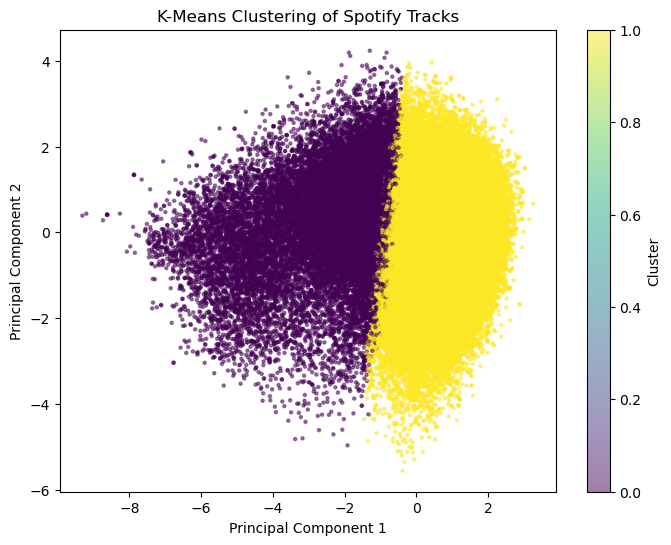

In [38]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap='viridis',
    s=5,
    alpha=0.5
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering of Spotify Tracks')
plt.colorbar(label='Cluster')
plt.show()

### Insight

PCA was used to reduce the selected audio features to two dimensions for visualization. The scatter plot shows some overlap between the two clusters. This indicates that the groups are not completely distinct in the two-dimensional representation. However, PCA visualization does not show all the information contained in the original features.

## Hierarchial Clustering

In [39]:
# Take a sample of 3000 songs

X_sample = X_scaled.sample(
    n=3000,
    random_state=42
)

print("Sample shape:", X_sample.shape)

Sample shape: (3000, 10)


In [40]:
## Hierarchical clustering model

from sklearn.cluster import AgglomerativeClustering

hierarchical_model = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward'
)

hierarchical_labels = hierarchical_model.fit_predict(X_sample)

print("Number of clusters:", len(set(hierarchical_labels)))
print("\nCluster counts:")
print(
    pd.Series(hierarchical_labels)
    .value_counts()
    .sort_index()
)

Number of clusters: 2

Cluster counts:
0    2275
1     725
Name: count, dtype: int64


In [41]:
## Evaluate the clustering model

from sklearn.metrics import silhouette_score, davies_bouldin_score

hierarchical_silhouette = silhouette_score(
    X_sample,
    hierarchical_labels
)

hierarchical_db = davies_bouldin_score(
    X_sample,
    hierarchical_labels
)

print("Hierarchical Silhouette Score:",
      round(hierarchical_silhouette, 4))

print("Hierarchical Davies-Bouldin Index:",
      round(hierarchical_db, 4))

Hierarchical Silhouette Score: 0.1789
Hierarchical Davies-Bouldin Index: 1.9451


### Insight

Hierarchical Clustering was applied to a sample of 3,000 tracks and divided them into two clusters. The Silhouette Score was approximately 0.179, and the Davies-Bouldin Index was 1.945. These results indicate that the clusters have limited separation in this sample.

## DBSCAN

In [42]:
from sklearn.cluster import DBSCAN

dbscan_model = DBSCAN(
    eps=0.8,
    min_samples=10
)

dbscan_labels = dbscan_model.fit_predict(X_sample)

print("Cluster labels:", set(dbscan_labels))
print("\nCluster counts:")
print(
    pd.Series(dbscan_labels)
    .value_counts()
    .sort_index()
)

Cluster labels: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(-1)}

Cluster counts:
-1    2803
 0     157
 1      23
 2       9
 3       8
Name: count, dtype: int64


In [43]:
## Evaluate DBSCAN


from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

# Exclude noise points for evaluation
mask = dbscan_labels != -1

X_dbscan_eval = X_sample.iloc[np.where(mask)[0]]
labels_dbscan_eval = dbscan_labels[mask]

n_clusters = len(set(labels_dbscan_eval))

if n_clusters >= 2:
    silhouette_dbscan = silhouette_score(
        X_dbscan_eval,
        labels_dbscan_eval
    )

    db_dbscan = davies_bouldin_score(
        X_dbscan_eval,
        labels_dbscan_eval
    )

    print("Silhouette Score:", round(silhouette_dbscan, 4))
    print("Davies-Bouldin Index:", round(db_dbscan, 4))
else:
    print("Not enough clusters for evaluation.")

Silhouette Score: 0.138
Davies-Bouldin Index: 1.2202


## Visualize the hierarchical clustering

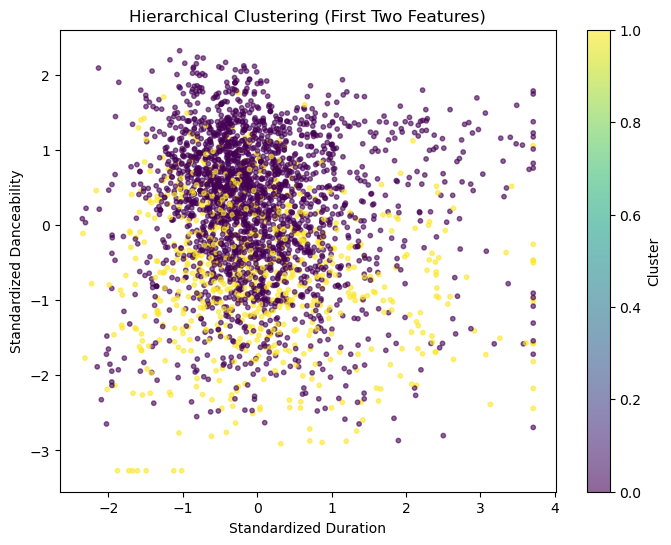

In [44]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_sample.iloc[:, 0],
    X_sample.iloc[:, 1],
    c=hierarchical_labels,
    cmap='viridis',
    s=10,
    alpha=0.6
)

plt.xlabel('Standardized Duration')
plt.ylabel('Standardized Danceability')
plt.title('Hierarchical Clustering (First Two Features)')
plt.colorbar(label='Cluster')
plt.show()

### Insight

DBSCAN identified a large number of tracks as noise and a few smaller clusters. Most tracks in the sample were labelled as noise (-1). This suggests that the selected DBSCAN parameters did not group most tracks into clusters. The evaluation scores were calculated only for non-noise tracks, so they should not be directly compared with the K-Means scores.

In [45]:
## save the K-Means model


import joblib

# Save model components
model_data = {
    'model': kmeans_final,
    'scaler': scaler,
    'features': features,
    'duration_limit': duration_limit
}

joblib.dump(model_data, 'spotify_clustering_model.pkl')

print("Model saved successfully!")

Model saved successfully!


### Insight

The trained K-Means model, fitted scaler, selected feature names, and duration limit were saved in a pickle file using joblib. Saving these components allows the same preprocessing steps and trained model to be reused in the Streamlit application without retraining the model.

## Conclusion

This project used unsupervised machine learning to discover patterns among Spotify tracks based on their audio features. K-Means, Hierarchical Clustering, and DBSCAN were applied to explore different clustering approaches.

K-Means grouped the tracks into two broad clusters with different audio characteristics. One group generally had lower energy and higher acousticness, while the other had higher energy and danceability.

The evaluation results showed that the clusters were not completely separated. Therefore, the results should be interpreted as broad patterns rather than exact music genres.

Finally, the trained K-Means model was integrated into a Streamlit application to assign a cluster to a song based on its audio features. This project demonstrates how unsupervised learning can be used to explore similarities in music data.